# K-Means Distance Comparison

**Metode yang dibandingkan:** Euclidean, Manhattan, dan Cosine Distance

**Identitas:**
- Nama : Muhammad Rayhan Zamzami
- NIM : 244107020027
- Kelas : TI-3G
- Absen : 19


In [1]:
# =======================================================================
# 1. SETUP & IMPORT LIBRARY
# =======================================================================
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "outputKmeans"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("[INFO] Environment berhasil dikonfigurasi.")
print(f"[INFO] Random State: {RANDOM_STATE}")


[INFO] Environment berhasil dikonfigurasi.
[INFO] Random State: 42


In [2]:
# =======================================================================
# 2. LOAD DATASET & PREPROCESSING
# =======================================================================
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/ml-semester5/dataset/diabetes_012_health_indicators_BRFSS2015.csv'

df_raw = pd.read_csv(DATASET_PATH)

print(f"Data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
display(df_raw.head())

print("\nTipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value.")

# -------------------- Preprocessing --------------------
df = df_raw.copy()
n_awal = len(df)

# Buang kelas 1 (pra-diabetes), fokus ke diabetes vs tidak
df = df[df['Diabetes_012'] != 1]
print(f"\nSetelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")

# Buang kolom Income sesuai preprocessing sebelumnya
df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

# Hapus data duplikat
n_sebelum_dup = len(df)
df = df.drop_duplicates()
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

df = df.reset_index(drop=True)

# Pisahkan label dan fitur
y_label = df['Diabetes_012'].copy()
df_features = df.drop(columns=['Diabetes_012']).astype(float)

print(f"Jumlah fitur untuk clustering: {df_features.shape[1]}")
print(f"Daftar fitur: {list(df_features.columns)}")

# Standardisasi untuk Euclidean dan Manhattan
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)

# Normalisasi L2 untuk Cosine
normalizer = Normalizer(norm='l2')
X_norm = normalizer.fit_transform(X_scaled)

print(f"\nBentuk data siap clustering: {X_scaled.shape}")
print(f"Cek mean dan std: {X_scaled.mean():.4f} / {X_scaled.std():.4f}")


Mounted at /content/drive
Data awal: 253680 baris x 22 kolom


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0



Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value.

Setelah buang kelas 1      : 249049 baris (terbuang 4631)
Setelah buang kolom Income : 21 kolom
Setelah hapus duplikat     : 208858 baris (terbuang 40191)
Jumlah fitur untuk clustering: 20
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']

Bentuk data siap clustering: (208858, 20)
Cek mean dan std: -0.0000 / 1.0000


## 3. Penentuan Jumlah Klaster Optimal (Elbow Method)

Elbow Method digunakan untuk mencari nilai **k** yang memberikan penurunan SSE/Inertia yang mulai melandai. Nilai k yang sama digunakan pada ketiga metrik agar perbandingan lebih adil.

[RESULT] Titik siku optimal: k = 4


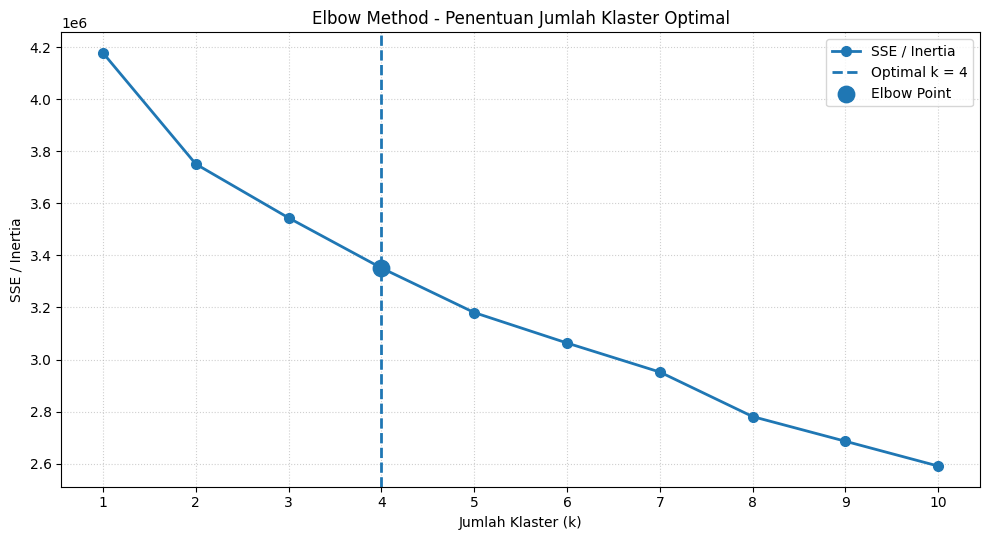

[SAVE] Grafik elbow disimpan: outputKmeans/elbow_curve.png


In [3]:
# =======================================================================
# 3. ELBOW METHOD & PENENTUAN K OPTIMAL
# =======================================================================
k_range = list(range(1, 11))
sse_list = []

for k in k_range:
    km_test = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=RANDOM_STATE
    )
    km_test.fit(X_scaled)
    sse_list.append(km_test.inertia_)

# Deteksi elbow secara geometris
def calculate_optimal_elbow(k_vals, sses):
    points = np.column_stack((
        np.asarray(k_vals, dtype=float),
        np.asarray(sses, dtype=float)
    ))

    p1 = points[0]
    p2 = points[-1]
    line_vec = p2 - p1
    norm = np.linalg.norm(line_vec)

    if norm == 0:
        return int(k_vals[0])

    line_unit = line_vec / norm
    distances = []

    for point in points:
        relative = point - p1
        perpendicular = relative - np.dot(relative, line_unit) * line_unit
        distances.append(np.linalg.norm(perpendicular))

    return int(k_vals[int(np.argmax(distances))])

optimal_k = calculate_optimal_elbow(k_range, sse_list)

print(f"[RESULT] Titik siku optimal: k = {optimal_k}")

plt.figure(figsize=(10, 5.5))
plt.plot(k_range, sse_list, marker='o', markersize=7, linewidth=2,
         label='SSE / Inertia')
plt.axvline(
    optimal_k,
    linestyle='--',
    linewidth=2,
    label=f'Optimal k = {optimal_k}'
)
plt.scatter(
    [optimal_k],
    [sse_list[optimal_k - 1]],
    s=140,
    zorder=5,
    label='Elbow Point'
)

plt.title('Elbow Method - Penentuan Jumlah Klaster Optimal')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('SSE / Inertia')
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()

elbow_path = os.path.join(OUTPUT_DIR, 'elbow_curve.png')
plt.savefig(elbow_path, dpi=300)
plt.show()

print(f"[SAVE] Grafik elbow disimpan: {elbow_path}")


## 4. Implementasi K-Means Multi-Metrik

Implementasi menggunakan aturan pembaruan centroid yang sesuai dengan metrik:
- **Euclidean:** centroid menggunakan mean.
- **Manhattan:** centroid menggunakan median (K-Medians principle).
- **Cosine:** centroid menggunakan rata-rata vektor yang kemudian dinormalisasi ke unit sphere.

In [4]:
# =======================================================================
# 4. KELAS K-MEANS MULTI-METRIK JARAK
# =======================================================================
class CustomKMeans:
    def __init__(
        self,
        n_clusters=3,
        metric='euclidean',
        max_iter=300,
        tol=1e-4,
        random_state=42
    ):
        self.n_clusters = n_clusters
        self.metric = metric.lower()
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0
        self.n_iter_ = 0
        self.execution_time_ = 0.0

    def _compute_distance(self, X, centroids):
        return pairwise_distances(
            X,
            centroids,
            metric=self.metric
        )

    def _init_centroids(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples, _ = X.shape

        first_idx = rng.randint(n_samples)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            current_centroids = np.array(centroids)
            distances = self._compute_distance(X, current_centroids)
            min_distances = np.min(distances, axis=1)

            squared_distances = min_distances ** 2
            total = np.sum(squared_distances)

            if total == 0:
                probabilities = np.ones(n_samples) / n_samples
            else:
                probabilities = squared_distances / total

            next_idx = rng.choice(
                n_samples,
                p=probabilities
            )
            centroids.append(X[next_idx])

        centroids = np.array(centroids)

        if self.metric == 'cosine':
            norms = np.linalg.norm(
                centroids,
                axis=1,
                keepdims=True
            )
            norms[norms == 0] = 1e-10
            centroids = centroids / norms

        return centroids

    def _update_centroids(self, X, labels):
        centroids = np.zeros(
            (self.n_clusters, X.shape[1])
        )

        rng = np.random.RandomState(
            self.random_state
        )

        for k in range(self.n_clusters):
            cluster_pts = X[labels == k]

            if len(cluster_pts) == 0:
                centroids[k] = X[rng.randint(len(X))]

            elif self.metric == 'euclidean':
                centroids[k] = np.mean(
                    cluster_pts,
                    axis=0
                )

            elif self.metric == 'manhattan':
                centroids[k] = np.median(
                    cluster_pts,
                    axis=0
                )

            elif self.metric == 'cosine':
                mean_vec = np.mean(
                    cluster_pts,
                    axis=0
                )
                norm = np.linalg.norm(mean_vec)

                centroids[k] = (
                    mean_vec / norm
                    if norm > 0
                    else mean_vec
                )

        return centroids

    def fit(self, X):
        start_time = time.perf_counter()

        if self.metric == 'cosine':
            norms = np.linalg.norm(
                X,
                axis=1,
                keepdims=True
            )
            norms[norms == 0] = 1e-10
            X_calc = X / norms
        else:
            X_calc = X

        self.centroids = self._init_centroids(X_calc)

        for it in range(self.max_iter):
            self.n_iter_ = it + 1

            distances = self._compute_distance(
                X_calc,
                self.centroids
            )
            labels = np.argmin(
                distances,
                axis=1
            )

            new_centroids = self._update_centroids(
                X_calc,
                labels
            )

            centroid_shift = np.linalg.norm(
                new_centroids - self.centroids
            )

            self.centroids = new_centroids
            self.labels_ = labels

            if centroid_shift < self.tol:
                break

        final_distances = self._compute_distance(
            X_calc,
            self.centroids
        )

        assigned_distances = final_distances[
            np.arange(len(X_calc)),
            self.labels_
        ]

        self.inertia_ = float(
            np.sum(assigned_distances ** 2)
        )

        self.execution_time_ = float(
            time.perf_counter() - start_time
        )

        return self

    def predict(self, X):
        if self.metric == 'cosine':
            norms = np.linalg.norm(
                X,
                axis=1,
                keepdims=True
            )
            norms[norms == 0] = 1e-10
            X_calc = X / norms
        else:
            X_calc = X

        distances = self._compute_distance(
            X_calc,
            self.centroids
        )

        return np.argmin(
            distances,
            axis=1
        )

print("[INFO] CustomKMeans multi-metrik berhasil didefinisikan.")


[INFO] CustomKMeans multi-metrik berhasil didefinisikan.


In [5]:
# =======================================================================
# 5. EKSEKUSI 3 K-MEANS & EVALUASI
# =======================================================================
configurations = {
    'Euclidean': {
        'metric': 'euclidean',
        'X': X_scaled
    },
    'Manhattan': {
        'metric': 'manhattan',
        'X': X_scaled
    },
    'Cosine': {
        'metric': 'cosine',
        'X': X_norm
    }
}

models = {}
evaluation_rows = []

for name, config in configurations.items():
    print(f"[RUN] K-Means {name}...")

    model = CustomKMeans(
        n_clusters=optimal_k,
        metric=config['metric'],
        max_iter=100,
        tol=1e-4,
        random_state=RANDOM_STATE
    )

    model.fit(config['X'])
    models[name] = model

    X_eval = config['X']

    sil_sample = min(10000, len(X_eval))

    sil = float(
        silhouette_score(
            X_eval,
            model.labels_,
            metric=config['metric'],
            sample_size=sil_sample,
            random_state=RANDOM_STATE
        )
    )

    dbi = float(
        davies_bouldin_score(
            X_eval,
            model.labels_
        )
    )

    ch = float(
        calinski_harabasz_score(
            X_eval,
            model.labels_
        )
    )

    evaluation_rows.append({
        'Distance Metric': name,
        'Optimal k': optimal_k,
        'Jumlah Data': len(X_eval),
        'Jumlah Fitur': X_eval.shape[1],
        'Silhouette Score (↑)': round(sil, 4),
        'Davies-Bouldin Index (↓)': round(dbi, 4),
        'Calinski-Harabasz Index (↑)': round(ch, 2),
        'Execution Time (s) (↓)': round(
            model.execution_time_,
            5
        ),
        'Iterations': model.n_iter_,
        'Objective Value (↓)': round(
            model.inertia_,
            2
        )
    })

df_comparison = pd.DataFrame(evaluation_rows)

print("\n" + "=" * 120)
print("PERBANDINGAN K-MEANS EUCLIDEAN, MANHATTAN, DAN COSINE")
print("=" * 120)
display(df_comparison)
print("=" * 120)


[RUN] K-Means Euclidean...
[RUN] K-Means Manhattan...
[RUN] K-Means Cosine...

PERBANDINGAN K-MEANS EUCLIDEAN, MANHATTAN, DAN COSINE


,Distance Metric,Optimal k,Jumlah Data,Jumlah Fitur,Silhouette Score (↑),Davies-Bouldin Index (↓),Calinski-Harabasz Index (↑),Execution Time (s) (↓),Iterations,Objective Value (↓)
0,Euclidean,4,208858,20,0.0811,2.6378,17124.85,3.90986,43,3352501.30
1,Manhattan,4,208858,20,0.1299,2.9811,12961.67,0.95813,4,21663057.87
2,Cosine,4,208858,20,0.1642,2.8177,15784.16,3.60895,21,73183.98


In [6]:
# =======================================================================
# 6. PROFIL KLASTER & EKSPOR HASIL
# =======================================================================
df_clustered = df_features.copy()
df_clustered['Diabetes_012'] = y_label.values

for name, model in models.items():
    df_clustered[f'Cluster_{name}'] = model.labels_

print("Profil jumlah data dan persentase diabetes tiap metode:")

for name, model in models.items():
    cluster_col = f'Cluster_{name}'

    profil = df_clustered.groupby(
        cluster_col
    ).mean(numeric_only=True).round(3)

    profil['Jumlah Data'] = (
        df_clustered[cluster_col]
        .value_counts()
        .sort_index()
    )

    profil['% Diabetes'] = (
        df_clustered
        .groupby(cluster_col)['Diabetes_012']
        .apply(lambda s: (s == 2).mean() * 100)
        .round(2)
    )

    print(f"\n--- {name} ---")
    display(profil)

excel_path = os.path.join(
    OUTPUT_DIR,
    'kmeans_distance_comparison.xlsx'
)

with pd.ExcelWriter(
    excel_path,
    engine='openpyxl'
) as writer:
    df_comparison.to_excel(
        writer,
        sheet_name='Ringkasan_Evaluasi',
        index=False
    )
    df_clustered.to_excel(
        writer,
        sheet_name='Data_Terklaster',
        index=False
    )

csv_path = os.path.join(
    OUTPUT_DIR,
    'data_terklaster_kmeans.csv'
)

df_clustered.to_csv(
    csv_path,
    index=False
)

print(f"\n[SAVE] Excel : {excel_path}")
print(f"[SAVE] CSV   : {csv_path}")


Profil jumlah data dan persentase diabetes tiap metode:

--- Euclidean ---


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,PhysHlth,DiffWalk,Sex,Age,Education,Diabetes_012,Cluster_Manhattan,Cluster_Cosine,Jumlah Data,% Diabetes
Cluster_Euclidean,,,,,,,,,,,,,,,,,,,,,
0,0.847,0.643,0.992,29.518,0.516,0.045,0.147,0.735,0.612,0.781,...,1.922,0.112,0.516,9.718,4.921,0.455,2.024,1.414,73958,22.76
1,0.686,0.613,0.984,31.346,0.621,0.160,0.291,0.441,0.548,0.709,...,19.260,0.797,0.364,9.188,4.511,0.688,1.980,2.038,35502,34.38
2,0.333,0.319,0.860,28.810,0.493,0.025,0.059,0.697,0.568,0.763,...,4.064,0.139,0.486,6.116,4.528,0.222,1.157,1.344,11827,11.09
3,0.062,0.230,0.929,27.244,0.375,0.007,0.010,0.820,0.615,0.820,...,1.918,0.033,0.403,6.436,5.237,0.097,0.450,0.887,87571,4.86



--- Manhattan ---


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,PhysHlth,DiffWalk,Sex,Age,Education,Diabetes_012,Cluster_Euclidean,Cluster_Cosine,Jumlah Data,% Diabetes
Cluster_Manhattan,,,,,,,,,,,,,,,,,,,,,
0,0.227,0.246,0.948,27.295,0.298,0.022,0.042,0.822,0.757,0.841,...,2.512,0.066,0.287,7.410,5.286,0.151,2.249,0.836,98975,7.55
1,0.172,0.164,0.866,28.602,0.358,0.016,0.033,0.721,0.372,0.714,...,2.594,0.066,0.685,5.400,4.345,0.136,2.233,1.470,12000,6.78
2,0.760,0.672,0.983,31.455,0.634,0.127,0.250,0.319,0.660,0.736,...,17.091,0.829,0.255,9.560,4.408,0.709,0.869,2.015,32579,35.43
3,0.721,0.689,0.973,29.904,0.681,0.053,0.153,0.761,0.373,0.736,...,3.144,0.105,0.723,8.748,4.861,0.453,0.676,1.600,65304,22.63



--- Cosine ---


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,PhysHlth,DiffWalk,Sex,Age,Education,Diabetes_012,Cluster_Euclidean,Cluster_Manhattan,Jumlah Data,% Diabetes
Cluster_Cosine,,,,,,,,,,,,,,,,,,,,,
0,0.292,0.333,0.950,27.241,0.377,0.012,0.017,0.845,0.713,1.000,...,1.766,0.022,0.000,7.485,5.217,0.154,2.111,0.400,64236,7.72
1,0.401,0.398,0.942,28.492,0.473,0.017,0.070,0.829,0.624,1.000,...,1.462,0.020,1.000,7.489,5.175,0.248,1.652,1.557,53548,12.38
2,0.740,0.647,0.981,31.102,0.608,0.132,0.279,0.492,0.586,0.818,...,13.912,0.648,0.354,9.432,4.538,0.651,0.793,2.010,56238,32.53
3,0.416,0.406,0.952,28.642,0.436,0.026,0.063,0.683,0.377,0.000,...,1.947,0.064,0.537,7.713,4.847,0.271,1.527,1.463,34836,13.56



[SAVE] Excel : outputKmeans/kmeans_distance_comparison.xlsx
[SAVE] CSV   : outputKmeans/data_terklaster_kmeans.csv


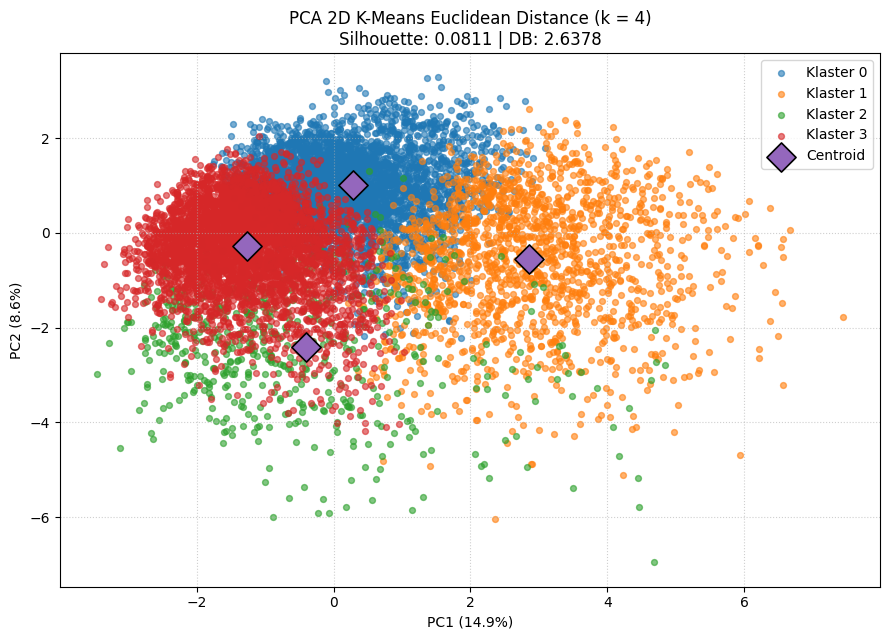

[SAVE] Euclidean: outputKmeans/cluster_euclidean.png


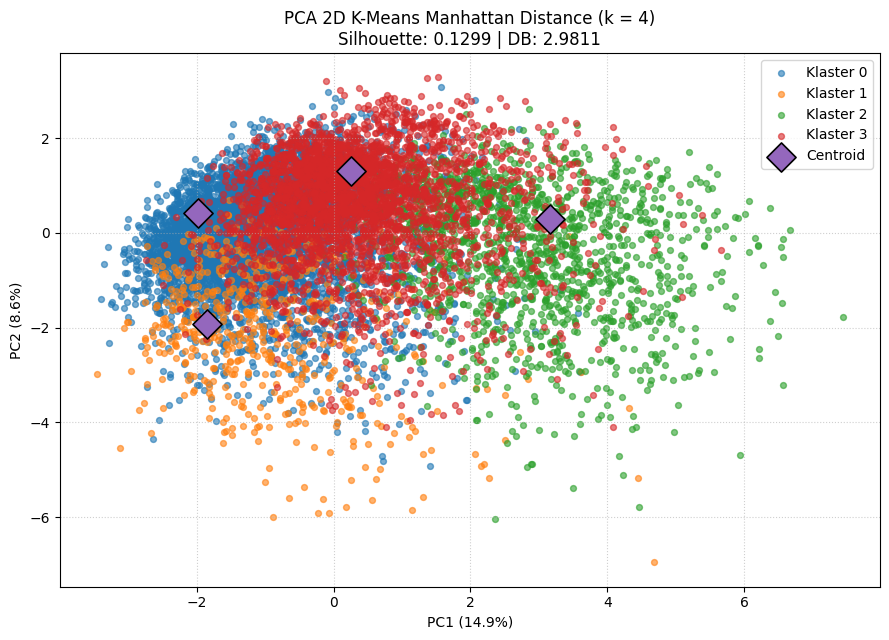

[SAVE] Manhattan: outputKmeans/cluster_manhattan.png


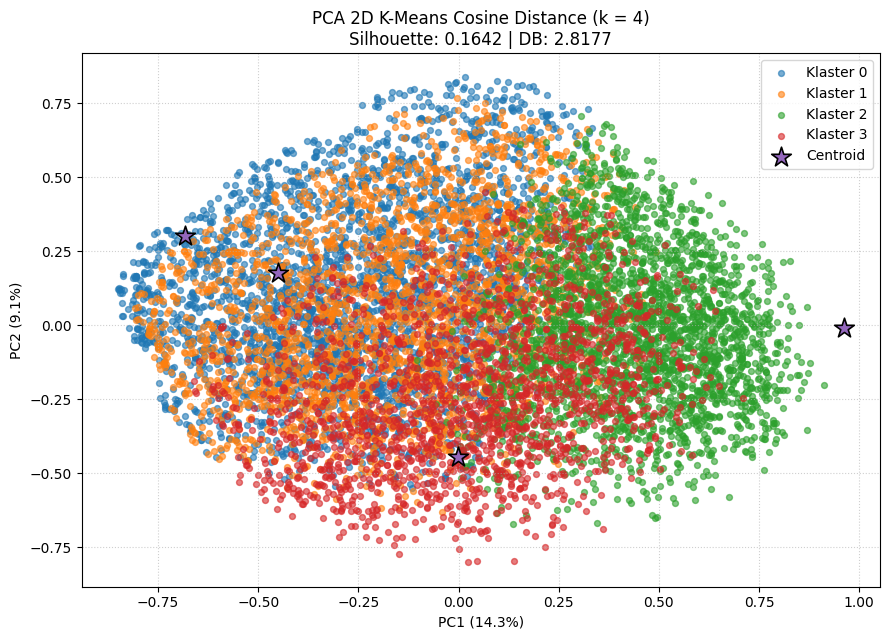

[SAVE] Cosine: outputKmeans/cluster_cosine.png


In [7]:
# =======================================================================
# 7. VISUALISASI PCA 2D
# =======================================================================
rng = np.random.RandomState(RANDOM_STATE)

PCA_SAMPLE_SIZE = min(10000, len(X_scaled))
vis_idx = rng.choice(
    len(X_scaled),
    PCA_SAMPLE_SIZE,
    replace=False
)

for name, model in models.items():
    X_source = (
        X_norm
        if name == 'Cosine'
        else X_scaled
    )

    pca = PCA(
        n_components=2,
        random_state=RANDOM_STATE
    )

    X_pca = pca.fit_transform(
        X_source[vis_idx]
    )

    centroids_pca = pca.transform(
        model.centroids
    )

    labels_sample = model.labels_[vis_idx]

    plt.figure(figsize=(9, 6.5))

    for k in range(optimal_k):
        mask = labels_sample == k

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=f'Klaster {k}',
            alpha=0.6,
            s=18
        )

    marker = '*' if name == 'Cosine' else 'D'

    plt.scatter(
        centroids_pca[:, 0],
        centroids_pca[:, 1],
        marker=marker,
        s=220,
        edgecolor='black',
        linewidth=1.2,
        label='Centroid',
        zorder=10
    )

    row = df_comparison[
        df_comparison['Distance Metric'] == name
    ].iloc[0]

    plt.title(
        f'PCA 2D K-Means {name} Distance '
        f'(k = {optimal_k})\n'
        f'Silhouette: {row["Silhouette Score (↑)"]:.4f} | '
        f'DB: {row["Davies-Bouldin Index (↓)"]:.4f}'
    )

    plt.xlabel(
        f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)'
    )
    plt.ylabel(
        f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)'
    )

    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()

    filename = f'cluster_{name.lower()}.png'
    path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    plt.savefig(
        path,
        dpi=300
    )

    plt.show()

    print(f"[SAVE] {name}: {path}")


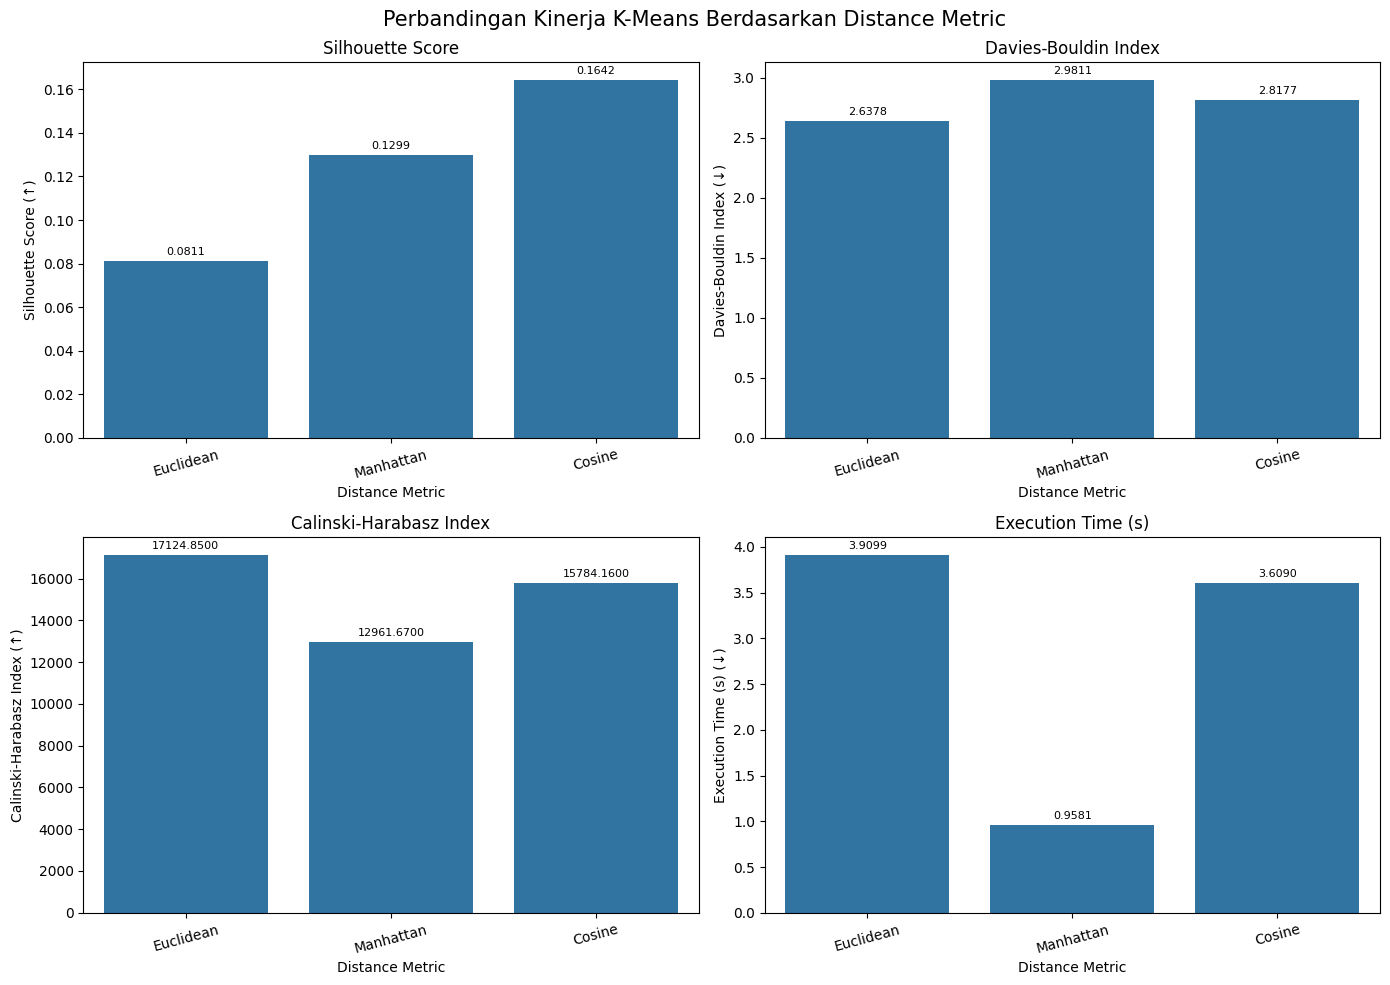

[SAVE] Bar chart disimpan: outputKmeans/comparison_metrics.png


In [8]:
# =======================================================================
# 8. BAR CHART PERBANDINGAN METRIK EVALUASI
# =======================================================================
metrics = [
    ('Silhouette Score (↑)', 'Silhouette Score'),
    ('Davies-Bouldin Index (↓)', 'Davies-Bouldin Index'),
    ('Calinski-Harabasz Index (↑)', 'Calinski-Harabasz Index'),
    ('Execution Time (s) (↓)', 'Execution Time (s)')
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

axes = axes.ravel()

for ax, (column, title) in zip(axes, metrics):
    sns.barplot(
        data=df_comparison,
        x='Distance Metric',
        y=column,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel('Distance Metric')
    ax.set_ylabel(column)
    ax.tick_params(axis='x', rotation=15)

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.4f',
            padding=3,
            fontsize=8
        )

plt.suptitle(
    'Perbandingan Kinerja K-Means Berdasarkan Distance Metric',
    fontsize=15
)

plt.tight_layout()

comparison_path = os.path.join(
    OUTPUT_DIR,
    'comparison_metrics.png'
)

plt.savefig(
    comparison_path,
    dpi=300
)

plt.show()

print(f"[SAVE] Bar chart disimpan: {comparison_path}")


## 9. Interpretasi Hasil

Gunakan tabel evaluasi dan grafik di atas untuk menentukan metode terbaik. **Silhouette Score** dan **Calinski-Harabasz** semakin besar semakin baik, sedangkan **Davies-Bouldin** dan waktu eksekusi semakin kecil semakin baik. Perhatikan juga bentuk persebaran klaster pada visualisasi PCA.

In [9]:
# =======================================================================
# 9. INTERPRETASI OTOMATIS
# =======================================================================
best_sil = df_comparison.loc[
    df_comparison['Silhouette Score (↑)'].idxmax(),
    'Distance Metric'
]

best_dbi = df_comparison.loc[
    df_comparison['Davies-Bouldin Index (↓)'].idxmin(),
    'Distance Metric'
]

best_ch = df_comparison.loc[
    df_comparison['Calinski-Harabasz Index (↑)'].idxmax(),
    'Distance Metric'
]

fastest = df_comparison.loc[
    df_comparison['Execution Time (s) (↓)'].idxmin(),
    'Distance Metric'
]

print("=" * 80)
print("INTERPRETASI HASIL K-MEANS")
print("=" * 80)
print(f"Silhouette Score terbaik       : {best_sil}")
print(f"Davies-Bouldin terbaik         : {best_dbi}")
print(f"Calinski-Harabasz terbaik      : {best_ch}")
print(f"Waktu eksekusi tercepat        : {fastest}")
print()
print(
    "Metode yang paling sesuai dapat dipilih dengan mempertimbangkan "
    "gabungan kualitas pemisahan klaster, compactness/separation, "
    "dan waktu eksekusi."
)
print("=" * 80)


INTERPRETASI HASIL K-MEANS
Silhouette Score terbaik       : Cosine
Davies-Bouldin terbaik         : Euclidean
Calinski-Harabasz terbaik      : Euclidean
Waktu eksekusi tercepat        : Manhattan

Metode yang paling sesuai dapat dipilih dengan mempertimbangkan gabungan kualitas pemisahan klaster, compactness/separation, dan waktu eksekusi.


In [10]:
# =======================================================================
# 10. NARRATIVE ANALYSIS AKHIR
# =======================================================================
from IPython.display import display, Markdown

# Ambil pemenang masing-masing metrik
best_sil_row = df_comparison.loc[
    df_comparison['Silhouette Score (↑)'].idxmax()
]
best_dbi_row = df_comparison.loc[
    df_comparison['Davies-Bouldin Index (↓)'].idxmin()
]
best_ch_row = df_comparison.loc[
    df_comparison['Calinski-Harabasz Index (↑)'].idxmax()
]
best_runtime_row = df_comparison.loc[
    df_comparison['Execution Time (s) (↓)'].idxmin()
]

# Ranking gabungan:
# Silhouette dan CH -> semakin besar semakin baik
# DBI dan Runtime -> semakin kecil semakin baik
rank_df = df_comparison[['Distance Metric']].copy()

rank_df['rank_sil'] = (
    df_comparison['Silhouette Score (↑)']
    .rank(ascending=False, method='min')
    .values
)

rank_df['rank_dbi'] = (
    df_comparison['Davies-Bouldin Index (↓)']
    .rank(ascending=True, method='min')
    .values
)

rank_df['rank_ch'] = (
    df_comparison['Calinski-Harabasz Index (↑)']
    .rank(ascending=False, method='min')
    .values
)

rank_df['rank_runtime'] = (
    df_comparison['Execution Time (s) (↓)']
    .rank(ascending=True, method='min')
    .values
)

rank_df['average_rank'] = rank_df[
    ['rank_sil', 'rank_dbi', 'rank_ch', 'rank_runtime']
].mean(axis=1)

final_metric = rank_df.loc[
    rank_df['average_rank'].idxmin(),
    'Distance Metric'
]

# Nilai hasil masing-masing metode untuk narasi
def get_metric(metric_name, column):
    row = df_comparison[
        df_comparison['Distance Metric'] == metric_name
    ].iloc[0]
    return row[column]

sil_e = get_metric('Euclidean', 'Silhouette Score (↑)')
sil_m = get_metric('Manhattan', 'Silhouette Score (↑)')
sil_c = get_metric('Cosine', 'Silhouette Score (↑)')

db_e = get_metric('Euclidean', 'Davies-Bouldin Index (↓)')
db_m = get_metric('Manhattan', 'Davies-Bouldin Index (↓)')
db_c = get_metric('Cosine', 'Davies-Bouldin Index (↓)')

ch_e = get_metric('Euclidean', 'Calinski-Harabasz Index (↑)')
ch_m = get_metric('Manhattan', 'Calinski-Harabasz Index (↑)')
ch_c = get_metric('Cosine', 'Calinski-Harabasz Index (↑)')

rt_e = get_metric('Euclidean', 'Execution Time (s) (↓)')
rt_m = get_metric('Manhattan', 'Execution Time (s) (↓)')
rt_c = get_metric('Cosine', 'Execution Time (s) (↓)')

# Narasi karakteristik berdasarkan metrik
characteristics = {
    'Euclidean': {
        'performance': (
            'Bekerja baik ketika struktur klaster cenderung berbentuk '
            'spherical dan variasi fitur relatif seimbang.'
        ),
        'characteristic': (
            'Sensitif terhadap outlier karena selisih koordinat dikuadratkan. '
            'Standardisasi fitur diperlukan agar fitur dengan skala besar '
            'tidak mendominasi perhitungan jarak.'
        )
    },
    'Manhattan': {
        'performance': (
            'Menggunakan jarak absolut sehingga perubahan pada masing-masing '
            'dimensi dihitung secara linear.'
        ),
        'characteristic': (
            'Relatif lebih robust terhadap nilai ekstrem dibanding Euclidean. '
            'Pada implementasi ini pembaruan pusat menggunakan median '
            'sehingga mengikuti prinsip K-Medians.'
        )
    },
    'Cosine': {
        'performance': (
            'Berfokus pada orientasi atau arah vektor dan mengabaikan '
            'perbedaan magnitudo setelah data dinormalisasi.'
        ),
        'characteristic': (
            'Cocok ketika pola proporsi atau arah fitur lebih penting '
            'daripada besar absolut nilai fitur. Data dinormalisasi ke '
            'unit hypersphere sebelum perhitungan.'
        )
    }
}

metric_order = ['Euclidean', 'Manhattan', 'Cosine']

rows = []
for metric in metric_order:
    rows.append(
        f"| {metric} | "
        f"{get_metric(metric, 'Silhouette Score (↑)'):.4f} | "
        f"{get_metric(metric, 'Davies-Bouldin Index (↓)'):.4f} | "
        f"{get_metric(metric, 'Calinski-Harabasz Index (↑)'):.2f} | "
        f"{get_metric(metric, 'Execution Time (s) (↓)'):.5f} |"
    )

comparison_table = "\n".join(rows)

text = f'''
# 📋 LAPORAN EVALUASI & REKOMENDASI TEKNIKAL

---

### 🏆 Hasil Evaluasi

1. **Metrik dengan Kohesi & Separasi Terbaik (Silhouette)**
   : **{best_sil_row["Distance Metric"]}** — {best_sil_row["Silhouette Score (↑)"]:.4f}

2. **Metrik dengan Separasi Klaster Paling Tegas (Davies-Bouldin)**
   : **{best_dbi_row["Distance Metric"]}** — {best_dbi_row["Davies-Bouldin Index (↓)"]:.4f}

3. **Metrik dengan Dispersi Klaster Terendah / Separasi Tertinggi (Calinski-H.)**
   : **{best_ch_row["Distance Metric"]}** — {best_ch_row["Calinski-Harabasz Index (↑)"]:.2f}

4. **Metrik dengan Efisiensi Komputasi Tertinggi (Runtime)**
   : **{best_runtime_row["Distance Metric"]}** — {best_runtime_row["Execution Time (s) (↓)"]:.5f} detik

---

## 🔎 Perbandingan Nilai Evaluasi

| Distance Metric | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ | Runtime ↓ |
|---|---:|---:|---:|---:|
{comparison_table}

---

## 🔍 Analisis Komprehensif Karakteristik Metrik Jarak

### 1. Euclidean Distance (L₂)

- **Performa:** {characteristics["Euclidean"]["performance"]}
- **Karakteristik:** {characteristics["Euclidean"]["characteristic"]}

### 2. Manhattan Distance (L₁)

- **Performa:** {characteristics["Manhattan"]["performance"]}
- **Karakteristik:** {characteristics["Manhattan"]["characteristic"]}

### 3. Cosine Similarity / Cosine Distance

- **Performa:** {characteristics["Cosine"]["performance"]}
- **Karakteristik:** {characteristics["Cosine"]["characteristic"]}

---

## 📌 Kesimpulan & Rekomendasi Terapan

Berdasarkan **ranking gabungan empat indikator evaluasi**, yaitu Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index, dan Execution Time, **{final_metric} Distance** memperoleh performa keseluruhan terbaik pada dataset ini.

Rekomendasi tersebut tidak hanya mempertimbangkan satu nilai evaluasi, tetapi mempertimbangkan keseimbangan antara **kohesi intraklaster, separasi antarklaster, dispersi klaster, dan efisiensi komputasi**. Dengan demikian, {final_metric} Distance dapat dipilih sebagai pendekatan utama untuk proses clustering pada dataset yang digunakan.

> **Catatan:** nilai dan pemenang pada bagian ini dihasilkan otomatis dari hasil eksekusi notebook, sehingga narasi akan mengikuti hasil aktual dataset.
'''

display(Markdown(text))



# 📋 LAPORAN EVALUASI & REKOMENDASI TEKNIKAL

---

### 🏆 Hasil Evaluasi

1. **Metrik dengan Kohesi & Separasi Terbaik (Silhouette)**  
   : **Cosine** — 0.1642

2. **Metrik dengan Separasi Klaster Paling Tegas (Davies-Bouldin)**  
   : **Euclidean** — 2.6378

3. **Metrik dengan Dispersi Klaster Terendah / Separasi Tertinggi (Calinski-H.)**  
   : **Euclidean** — 17124.85

4. **Metrik dengan Efisiensi Komputasi Tertinggi (Runtime)**  
   : **Manhattan** — 0.95813 detik

---

## 🔎 Perbandingan Nilai Evaluasi

| Distance Metric | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ | Runtime ↓ |
|---|---:|---:|---:|---:|
| Euclidean | 0.0811 | 2.6378 | 17124.85 | 3.90986 |
| Manhattan | 0.1299 | 2.9811 | 12961.67 | 0.95813 |
| Cosine | 0.1642 | 2.8177 | 15784.16 | 3.60895 |

---

## 🔍 Analisis Komprehensif Karakteristik Metrik Jarak

### 1. Euclidean Distance (L₂)

- **Performa:** Bekerja baik ketika struktur klaster cenderung berbentuk spherical dan variasi fitur relatif seimbang.
- **Karakteristik:** Sensitif terhadap outlier karena selisih koordinat dikuadratkan. Standardisasi fitur diperlukan agar fitur dengan skala besar tidak mendominasi perhitungan jarak.

### 2. Manhattan Distance (L₁)

- **Performa:** Menggunakan jarak absolut sehingga perubahan pada masing-masing dimensi dihitung secara linear.
- **Karakteristik:** Relatif lebih robust terhadap nilai ekstrem dibanding Euclidean. Pada implementasi ini pembaruan pusat menggunakan median sehingga mengikuti prinsip K-Medians.

### 3. Cosine Similarity / Cosine Distance

- **Performa:** Berfokus pada orientasi atau arah vektor dan mengabaikan perbedaan magnitudo setelah data dinormalisasi.
- **Karakteristik:** Cocok ketika pola proporsi atau arah fitur lebih penting daripada besar absolut nilai fitur. Data dinormalisasi ke unit hypersphere sebelum perhitungan.

---

## 📌 Kesimpulan & Rekomendasi Terapan

Berdasarkan **ranking gabungan empat indikator evaluasi**, yaitu Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index, dan Execution Time, **Cosine Distance** memperoleh performa keseluruhan terbaik pada dataset ini.

Rekomendasi tersebut tidak hanya mempertimbangkan satu nilai evaluasi, tetapi mempertimbangkan keseimbangan antara **kohesi intraklaster, separasi antarklaster, dispersi klaster, dan efisiensi komputasi**. Dengan demikian, Cosine Distance dapat dipilih sebagai pendekatan utama untuk proses clustering pada dataset yang digunakan.

> **Catatan:** nilai dan pemenang pada bagian ini dihasilkan otomatis dari hasil eksekusi notebook, sehingga narasi akan mengikuti hasil aktual dataset.
